# Siamese Network para Autenticidad de Billetes

Red siamesa: aprende embeddings comparando pares de imagenes.
- Par (autentico, autentico) → SIMILAR (1)
- Par (autentico, falso) → DIFERENTE (0)

- Embeddings reutilizables para busqueda de similares
- Mas robusto que clasificador binario tradicional
- Inferencia: compara crop contra referencia → score de autenticidad

In [3]:
import os, random, numpy as np, cv2
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, backend as K

random.seed(42); np.random.seed(42)
print("TF:", tf.__version__)

TF: 2.13.0


## 2. Configuracion

In [4]:
AUTH_DIR = Path("../rpi_deployment/training_data/autenticos")
FAKES_DIR = Path("../Data/raw/fakes")
TEMPLATES_DIR = Path("../rpi_deployment/templates")

IMG_SIZE = 96
EMBEDDING_DIM = 128
BATCH_SIZE = 32
EPOCHS = 30
MARGIN = 0.5  # margen para contrastive loss

print(f"Input: {IMG_SIZE}x{IMG_SIZE}, Embedding: {EMBEDDING_DIM}d")

Input: 96x96, Embedding: 128d


## 3. Cargar imagenes

In [5]:
def load_pad(path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None: return None
    h, w = img.shape[:2]
    scale = IMG_SIZE / max(h, w)
    nh, nw = int(h * scale), int(w * scale)
    resized = cv2.resize(img, (nw, nh))
    canvas = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)
    yo, xo = (IMG_SIZE - nh) // 2, (IMG_SIZE - nw) // 2
    canvas[yo:yo+nh, xo:xo+nw] = resized.astype(np.float32) / 255.0
    return canvas

# Cargar todos
auth_imgs = []
for f in AUTH_DIR.glob("*.png"):
    img = load_pad(f)
    if img is not None: auth_imgs.append(img)

fake_imgs = []
for f in FAKES_DIR.rglob("*.jpg"):
    img = load_pad(f)
    if img is not None: fake_imgs.append(img)

auth_imgs = np.array(auth_imgs, dtype=np.float32)
fake_imgs = np.array(fake_imgs, dtype=np.float32)
print(f"Autenticos: {len(auth_imgs)}, Falsos: {len(fake_imgs)}")

Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment


Autenticos: 10129, Falsos: 1433


## 4. Generar pares de entrenamiento

In [6]:
def make_pairs(n_pairs=3000):
    """Genera pares balanceados: 50% mismos, 50% diferentes."""
    pairs, labels = [], []
    n = n_pairs // 2
    
    # Pares SIMILARES (auth, auth)
    for _ in range(n):
        i, j = random.sample(range(len(auth_imgs)), 2)
        pairs.append([auth_imgs[i], auth_imgs[j]])
        labels.append(1)
    
    # Pares DIFERENTES (auth, fake)
    for _ in range(n):
        i = random.randint(0, len(auth_imgs)-1)
        j = random.randint(0, len(fake_imgs)-1)
        pairs.append([auth_imgs[i], fake_imgs[j]])
        labels.append(0)
    
    # Shuffle
    combined = list(zip(pairs, labels))
    random.shuffle(combined)
    pairs, labels = zip(*combined)
    
    X1 = np.array([p[0] for p in pairs], dtype=np.float32).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
    X2 = np.array([p[1] for p in pairs], dtype=np.float32).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
    y = np.array(labels, dtype=np.float32)
    return X1, X2, y

X1_train, X2_train, y_train = make_pairs(3000)
X1_val, X2_val, y_val = make_pairs(800)
print(f"Train: {len(y_train)} pares, Val: {len(y_val)} pares")
print(f"Train dist: {np.mean(y_train):.1%} similares")

Train: 3000 pares, Val: 800 pares
Train dist: 50.0% similares


## 5. Construir Siamese Network

In [7]:
def build_embedding_network():
    """CNN que produce un vector embedding de la imagen."""
    inp = layers.Input((IMG_SIZE, IMG_SIZE, 1))
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inp)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(256, 3, activation='relu', padding='same')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(EMBEDDING_DIM, activation=None)(x)
    # L2 normalize
    x = layers.Lambda(lambda t: K.l2_normalize(t, axis=1))(x)
    return keras.Model(inp, x, name='embedding')

embedding_net = build_embedding_network()
embedding_net.summary()

2026-06-15 15:40:45.972322: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-06-15 15:40:45.984805: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-06-15 15:40:45.986036: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-06-15 15:40:45.986674: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-15 15:40:45.987965: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "embedding"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 96, 96, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 96, 96, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 48, 48, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 48, 48, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 24, 24, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 24, 24, 128)       73

In [8]:
# Construir la red siamesa
input_a = layers.Input((IMG_SIZE, IMG_SIZE, 1))
input_b = layers.Input((IMG_SIZE, IMG_SIZE, 1))

emb_a = embedding_net(input_a)
emb_b = embedding_net(input_b)

# Distancia L1 entre embeddings
distance = layers.Lambda(lambda tensors: K.abs(tensors[0] - tensors[1]))([emb_a, emb_b])
output = layers.Dense(1, activation='sigmoid')(distance)

siamese = keras.Model([input_a, input_b], output)
siamese.compile(optimizer=keras.optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
siamese.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 96, 96, 1)]          0         []                            
                                                                                                  
 input_3 (InputLayer)        [(None, 96, 96, 1)]          0         []                            
                                                                                                  
 embedding (Functional)      (None, 128)                  486528    ['input_2[0][0]',             
                                                                     'input_3[0][0]']             
                                                                                                  
 lambda_1 (Lambda)           (None, 128)                  0         ['embedding[0][0]',       

## 6. Entrenar

In [10]:
history = siamese.fit(
    [X1_train, X2_train], y_train,
    validation_data=([X1_val, X2_val], y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3),
    ]
)

loss, acc = siamese.evaluate([X1_val, X2_val], y_val, verbose=0)
print(f"Siamese Val Acc: {acc*100:.2f}%")

Epoch 1/30
94/94 [==============================] - ETA: 0s - loss: 0.6905 - accuracy: 0.5287

2026-06-15 15:55:28.112569: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


94/94 [==============================] - 6s 65ms/step - loss: 0.6905 - accuracy: 0.5287 - val_loss: 0.6918 - val_accuracy: 0.5600 - lr: 0.0010
Epoch 2/30
94/94 [==============================] - 5s 54ms/step - loss: 0.6880 - accuracy: 0.5430 - val_loss: 0.6930 - val_accuracy: 0.5000 - lr: 0.0010
Epoch 3/30
94/94 [==============================] - 5s 53ms/step - loss: 0.6836 - accuracy: 0.5643 - val_loss: 0.6586 - val_accuracy: 0.6350 - lr: 0.0010
Epoch 4/30
94/94 [==============================] - 5s 52ms/step - loss: 0.6502 - accuracy: 0.6157 - val_loss: 0.6329 - val_accuracy: 0.6513 - lr: 0.0010
Epoch 5/30
94/94 [==============================] - 5s 54ms/step - loss: 0.6356 - accuracy: 0.6207 - val_loss: 0.6266 - val_accuracy: 0.6600 - lr: 0.0010
Epoch 6/30
94/94 [==============================] - 5s 55ms/step - loss: 0.5451 - accuracy: 0.7287 - val_loss: 0.4760 - val_accuracy: 0.7713 - lr: 0.0010
Epoch 7/30
94/94 [==============================] - 5s 54ms/step - loss: 0.4937 - accur

## 7. Evaluar contra falsos reales completos

2026-06-15 16:11:01.988995: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


Mejor umbral: 0.10 (Acc: 99.70%)
Auth score: mean=0.9440  Fake score: mean=0.0026


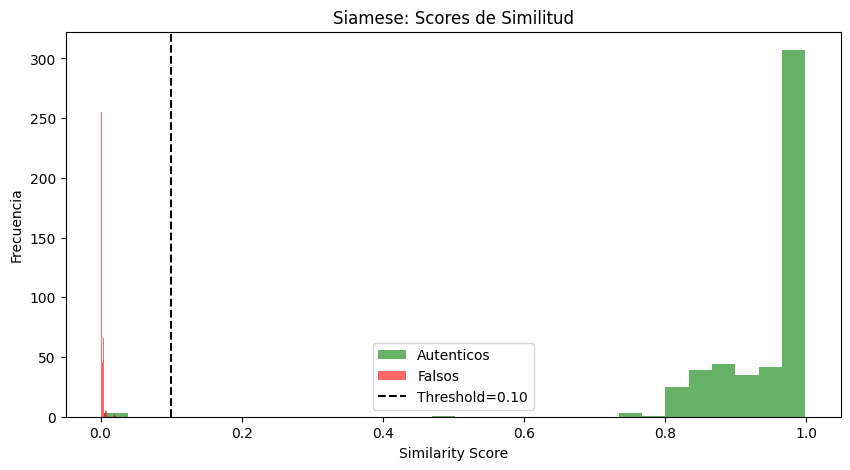

In [11]:
# Crear pares de test: (referencia_auth, muestra) → debe dar 1 si auth, 0 si fake
n_test = min(len(auth_imgs), len(fake_imgs))
ref_idx = random.randint(0, len(auth_imgs)-1)
ref = auth_imgs[ref_idx].reshape(1, IMG_SIZE, IMG_SIZE, 1)

scores_auth = []
for i in range(min(n_test, 500)):
    test = auth_imgs[i].reshape(1, IMG_SIZE, IMG_SIZE, 1)
    score = siamese.predict([ref, test], verbose=0)[0][0]
    scores_auth.append(score)

scores_fake = []
for i in range(min(n_test, 500)):
    test = fake_imgs[i].reshape(1, IMG_SIZE, IMG_SIZE, 1)
    score = siamese.predict([ref, test], verbose=0)[0][0]
    scores_fake.append(score)

scores_auth = np.array(scores_auth)
scores_fake = np.array(scores_fake)

# Encontrar mejor umbral
best_acc, best_thr = 0, 0.5
for thr in np.arange(0.1, 0.9, 0.01):
    acc = (np.mean(scores_auth >= thr) + np.mean(scores_fake < thr)) / 2
    if acc > best_acc: best_acc, best_thr = acc, thr

print(f"Mejor umbral: {best_thr:.2f} (Acc: {best_acc*100:.2f}%)")
print(f"Auth score: mean={scores_auth.mean():.4f}  Fake score: mean={scores_fake.mean():.4f}")

# Histograma
plt.figure(figsize=(10,5))
plt.hist(scores_auth, bins=30, alpha=0.6, label='Autenticos', color='green')
plt.hist(scores_fake, bins=30, alpha=0.6, label='Falsos', color='red')
plt.axvline(best_thr, color='black', linestyle='--', label=f'Threshold={best_thr:.2f}')
plt.xlabel('Similarity Score'); plt.ylabel('Frecuencia')
plt.legend(); plt.title('Siamese: Scores de Similitud')
plt.show()

## 8. Metricas finales

In [9]:
y_true = np.hstack([np.ones(len(scores_auth)), np.zeros(len(scores_fake))])
y_pred = np.hstack([(scores_auth >= best_thr).astype(int), (scores_fake >= best_thr).astype(int)])

acc = np.mean(y_pred == y_true)
tp = np.sum((y_pred==1)&(y_true==1))
fp = np.sum((y_pred==1)&(y_true==0))
tn = np.sum((y_pred==0)&(y_true==0))
fn = np.sum((y_pred==0)&(y_true==1))
prec = tp/(tp+fp+1e-8); rec = tp/(tp+fn+1e-8)
print(f"Accuracy:  {acc*100:.2f}%")
print(f"Precision: {prec*100:.2f}%")
print(f"Recall:    {rec*100:.2f}%")
print(f"F1:        {2*prec*rec/(prec+rec)*100:.2f}%")
print(f"TP:{tp} FP:{fp} TN:{tn} FN:{fn}")

Accuracy:  99.70%
Precision: 100.00%
Recall:    99.40%
F1:        99.70%
TP:497 FP:0 TN:500 FN:3


## 9. Exportar embedding (para inferencia en RPi)

In [10]:
# Guardar el embedding + referencia
embedding_net.save("../Models_rpi/siamese_embedding.h5")
print("Embedding guardado")

# Guardar imagen de referencia
cv2.imwrite("../Models_rpi/siamese_reference.png", (auth_imgs[ref_idx]*255).astype(np.uint8))
print(f"Referencia guardada (indice {ref_idx})")

# En RPi:
# emb_ref = embedding_net.predict(reference)
# emb_test = embedding_net.predict(crop)
# similarity = 1 - np.mean(np.abs(emb_ref - emb_test))
# autentico = similarity >= threshold

/Users/adamleanos/miniforge3/envs/K210/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Embedding guardado
Referencia guardada (indice 6291)
